In [1]:
# # for colab runs only
# from google.colab import drive
# drive.mount('/content/drive')
# import os
# os.chdir('/content/drive/MyDrive/nlp_project/bert_run0')


In [2]:
import sys
if 'google.colab' in sys.modules:
    from IPython.core.getipython import get_ipython
    get_ipython().run_line_magic("pip", "install transformers sentencepiece accelerate")
    #get_ipython().run_line_magic("pip", "install git+https://github.com/UlisseMini/activation_additions_hf")

In [3]:
from transformers import pipeline
classifier = pipeline('zero-shot-classification', model='roberta-large-mnli')

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
import torch
import math
import activation_additions as aa
import random as pyrandom

import os
import csv

from typing import Dict, Union, Callable, Tuple, List
from functools import partial
from transformers import AutoModelForCausalLM, AutoTokenizer
from activation_additions.compat import get_x_vector, get_n_steered_completions, get_n_baseline_completions
from functools import lru_cache
import matplotlib.pyplot as plt
from numpy import random

import nltk
from nltk.tokenize import PunktTokenizer
from tqdm.notebook import tqdm

from numpy import array,polyfit

from datasets import load_dataset

In [5]:
device: str = "mps" if torch.has_mps else "cuda" if torch.cuda.is_available() else "cpu"
_ = torch.set_grad_enabled(False)
device

C:\Users\oribr\AppData\Local\Temp\ipykernel_45840\1209224586.py:1: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  device: str = "mps" if torch.has_mps else "cuda" if torch.cuda.is_available() else "cpu"


'cuda'

In [6]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\oribr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
MODEL = "openai-community/gpt2-xl"
model = AutoModelForCausalLM.from_pretrained(MODEL).to(device)
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model.to_str_tokens = lambda t: [t.replace('Ġ', ' ') for t in tokenizer.tokenize(t)]
model.tokenizer = tokenizer
# In steering experimentation spaces were found to work well, this makes no sense and I hate it.
tokenizer.pad_token_id = int(model.tokenizer.encode(" ")[-1])
model.generation_config.pad_token_id = tokenizer.pad_token_id

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2-xl
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...47}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
NUM_BLOCKS = len(aa.get_blocks(model)) #*********************



In [12]:
sampling_kwargs: Dict[str, Union[float, int]] = {
    "temperature": 0.6,
    "top_p": 0.5,
    "freq_penalty": 1.0,
    # "num_comparisons": 3,
    "tokens_to_generate": 50,
    "seed": 0,  # For reproducibility
}
get_x_vector_preset: Callable = partial(
    get_x_vector,
    pad_method="tokens_right",
    model=model,
    custom_pad_id=tokenizer.pad_token_id,
)

In [13]:
@lru_cache(maxsize=1000)
def get_diff_vector(prompt_add: str, prompt_sub: str, layer: int):
    return aa.get_diff_vector(model, tokenizer, prompt_add, prompt_sub, layer)


@lru_cache
def run_aa(act_diff, layer, texts: tuple[str], loss_ignore_mod_tokens: bool = False):
    # todo: could compute act_diff for all layers at once, then a single fwd pass of cost for changing layer.
    blocks = aa.get_blocks(model)
    with aa.pre_hooks([(blocks[layer], aa.get_hook_fn(act_diff))]):
        inputs = tokenizer(list(texts), return_tensors='pt', padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        output = model(**inputs,output_hidden_states=True, return_dict=True)

    logprobs = torch.log_softmax(output.logits.to(torch.float32), -1)
    token_loss = -logprobs[..., :-1, :].gather(dim=-1, index=inputs['input_ids'][..., 1:, None])[..., 0]
    return token_loss

In [14]:
from pandas import read_csv
csv_file = read_csv("the_almost_ultimate_final(trimming_concepts).csv").to_dict()
concept_indexed = {}
dcat_indexed = {}
for j in csv_file["Concept"]:
    cur_data = {}
    for i in csv_file:
        cur_data[i] = csv_file[i][j]
    concept_indexed[csv_file["Concept"][j]] = cur_data
    for i in cur_data["Dataset Categories"].split(', '):
        dcat_indexed[i] = cur_data["Concept"]
print(concept_indexed)
print(dcat_indexed)

{'Academic Journal': {'Concept': 'Academic Journal', 'Dataset Categories': 'AcademicJournal', 'Keywords': 'journal, journals, peer-reviewed, publication, publications, article, articles, scholarly, citation, citations, abstract, abstracts, DOI, methodology, authors, publisher, impact factor, review, reviewer, published, volume, issue, manuscript, preprint', 'Positive Prompt Type 1': 'Academic Journal', 'Negative Prompt Type 1': ' ', 'Positive Prompt Type 2': 'I talk about academic journals constantly', 'Negative Prompt Type 2': 'I do not talk about academic journals constantly', 'Positive Label': 'This text relates to academic journals', 'Negative Label': 'This text does not relate to academic journals'}, 'Adult Film Actor': {'Concept': 'Adult Film Actor', 'Dataset Categories': 'AdultActor', 'Keywords': 'pornstar, pornstars, porn, adult film, erotic, pornography, adult actress, adult actor, pornographic, hardcore, softcore, adult entertainment, camgirl, adult industry, explicit, adult 

In [13]:
dataset = load_dataset("DeveloperOats/DBPedia_Classes")

di = dict()
pbar = tqdm()
pbar.reset(total=len(dataset["train"]))
for i in dataset["train"]:
    di[i["l3"]] = di.get(i["l3"],[]) + [i["text"]]
    pbar.update()
pbar = tqdm()
pbar.reset(total=len(dataset["validation"]))
for i in dataset["validation"]:
    di[i["l3"]] = di.get(i["l3"],[]) + [i["text"]]
    pbar.update()
pbar = tqdm()
pbar.reset(total=len(dataset["test"]))
for i in dataset["test"]:
    di[i["l3"]] = di.get(i["l3"],[]) + [i["text"]]
    pbar.update()
print("done")



0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

done


In [12]:
di_merged = {}
pbar = tqdm()
pbar.reset(total=len(di))
for i in di:
    di_merged[dcat_indexed[i]] = di_merged.get(dcat_indexed[i],[]) + di[i]
    pbar.update()


0it [00:00, ?it/s]

KeyError: 'TradeUnion'

In [15]:
import re
def get_prompt_add(concept: str, s_type=1) -> str:
    return concept_indexed[concept]["Positive Prompt Type "+str(s_type)]
    
def get_prompt_sub(concept: str,s_type=1) -> str:
    return concept_indexed[concept]["Negative Prompt Type "+str(s_type)]

def score_text_on_keywords(s: str, keywords: list[str]):
    text_tokenized = re.findall(r'\b\w+\b', s.lower())
    return sum(1 for word in text_tokenized if word in keywords)/len(text_tokenized)

def get_test_texts(concept: str, docs=100) -> dict[str,float]:
    if len(di_merged[concept]) < docs:
        raise("Not enough documents relating to "+concept)
    rel_docs = random.choice(di_merged[concept],docs)
    unrel_keys = list(di_merged.keys())
    unrel_keys.remove(concept)
    unrel_subjects = random.choice(unrel_keys,docs,replace=True)
    unrel_docs = []
    for i in unrel_subjects:
        unrel_docs.append(di_merged[i][random.randint(0,len(di_merged[i]))])
    ans_dict = {}
    for i in rel_docs:
        #print(i)
        # Round to percission of 0.5%
        ans_dict[str(i)] = round(score_text_on_keywords(i,concept_indexed[concept]["Keywords"].split(','))*200)/200
    for i in unrel_docs:
        #print(i)
        ans_dict[str(i)] = round(score_text_on_keywords(i,concept_indexed[concept]["Keywords"].split(','))*200)/200
    return ans_dict

## Perplexity

In [11]:
def calculate_perplexity_change(args_obj):
    sent_detector = PunktTokenizer()
    texts = tuple(args_obj['texts'].keys())
    loss_diff_in_bin = dict()
    element_count_in_bin = dict()
    #pbar = tqdm()
    #pbar.reset(total=len(texts)*2)
    diff_vector =  args_obj["coeff"] * get_diff_vector(args_obj["prompt_add"], args_obj["prompt_sub"], args_obj["layer"])
    diff_vector_base =  0 * get_diff_vector(' ', ' ', 0)
    #for text in texts:
    #prompt_add_len,prompt_sub_len = args_obj["prompt_add"],args_obj["prompt_sub"]
        #sentences = tuple(sent for sent in sent_detector.tokenize(text.strip()) if (len(sent) >= len(prompt_add_len)) and len(sent) >= len(prompt_sub_len))
    print("Started")
    token_loss = list(run_aa(diff_vector,args_obj["layer"],texts=(i,)) for i in texts)
    print("Starting base")
    abs_token_loss =list(run_aa(diff_vector_base,args_obj["layer"],texts=(i,)) for i in texts)
    print("Finished")
    mean_text_log_loss = [i.mean() for i in token_loss]
    abs_mean_text_log_loss = [i.mean() for i in abs_token_loss]
    for ind,i in enumerate(texts):
        print(i)
        print(mean_text_log_loss[ind])
        print(abs_mean_text_log_loss[ind])
    for i in range(len(texts)):
        rel_bin = args_obj['texts'][texts[i]]
        loss_diff_in_bin[rel_bin] = loss_diff_in_bin.get(rel_bin,0) + (mean_text_log_loss[i] - abs_mean_text_log_loss[i])
        element_count_in_bin[rel_bin] = element_count_in_bin.get(rel_bin,0) + 1
    print(loss_diff_in_bin)
    x = []
    y = []
    for bin in loss_diff_in_bin:
        perplexity_diff_in_bin = math.exp(loss_diff_in_bin[bin]/element_count_in_bin[rel_bin])
        x.append(bin)
        y.append(perplexity_diff_in_bin)
    t = sorted(zip(x,y))
    x,y = zip(*t)
    plt.plot(x,y)
    plt.show()
    #print(list(zip(x,y)))
    slope,_ = polyfit(x,y,1)
    print("Done")
    return slope

Started
Starting base
Finished
Oh Kwang-Soo (Hangul: 오광수) (born October 30, 1965 in Goheung, Jeollanam-do, South Korea) is a former South Korean boxer.
tensor(2.4943, device='cuda:0')
tensor(2.0880, device='cuda:0')
Alexander Espinoza Hernández (born December 27, 1980 in Caracas) is a bantamweight boxer from Venezuela, who represented his native country at the 2004 Summer Olympics in Athens, Greece. He qualified for the Olympic Games by ending up in second place at the 2nd AIBA American 2004 Olympic Qualifying Tournament in Rio de Janeiro, Brazil. He won the bronze medal in the men's bantanweight division (– 54 kg) at the 2002 Central American and Caribbean Games in El Salvador.
tensor(2.6132, device='cuda:0')
tensor(2.4019, device='cuda:0')
Lekha K. C. represented Indian Women's Amateur boxing at 75 kg category and won Gold medal in 2006 Women's World Amateur Boxing Championships.
tensor(4.2869, device='cuda:0')
tensor(3.8353, device='cuda:0')
Naim Terbunja (born 28 September 1984 in 

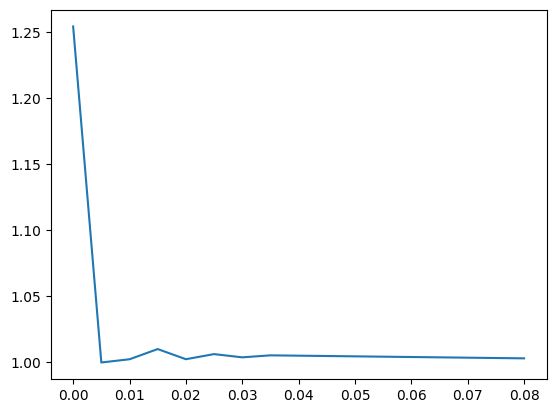

Done


np.float64(-1.3510924208241917)

In [63]:
def calculate_steering_efficacy_over_concept(concept, coeff, layer):
    summand_dict = {
        "coeff":coeff,
        "layer":layer,
        "prompt_add":get_prompt_add(concept),
        "prompt_sub":get_prompt_sub(concept),
        "texts": get_test_texts(concept),
        "loss_ignore_mod_tokens":False
    }
    return calculate_perplexity_change(summand_dict)
calculate_steering_efficacy_over_concept("Boxing",2,0)

In [15]:
new_summand = {
    "coeff": 2,
    "layer": 0,
    "prompt_add":get_prompt_add("Boxing"),
    "prompt_sub":get_prompt_sub("Boxing"),
    "texts": {
        "The Boxer boxes with his boxing gloves boxingly": 1,
        "Trees Trees Trees Trees Trees": 0
    }
}
calculate_perplexity_change(new_summand)

NameError: name 'calculate_perplexity_change' is not defined

In [16]:
def P(E,E_next,temp):
    prob = math.exp(-(E_next-E)/temp)
    if (prob > 1): return True
    else: return random.binomial(1,prob)

def random_neighbor(coeff,layer,coeff_delta = 0.1):
    coeff_opts = [0]
    if coeff > coeff_delta: coeff_opts.append(-coeff_delta)
    if coeff < 15: coeff_opts.append(coeff_delta)
    coeff_d = random.choice(coeff_opts)
    layer_opts = []
    if coeff_d != 0: layer_opts.append(0)
    if layer > 0: layer_opts.append(-1)
    if layer < model.config.num_hidden_layers-1: layer_opts.append(1)
    layer_d = random.choice(layer_opts)
    return coeff + coeff_d,layer + layer_d

    

def basic_hyperparamter_optimization(concept,k_max=100, init_temp = 10, decay_rate = 0.99):
    coeff,layer = random.uniform(0.01,8),random.randint(0,model.config.num_hidden_layers//2)
    E = calculate_steering_efficacy_over_concept(concept,coeff,layer)
    print("Starting:",coeff,layer,E)
    T = init_temp
    best_E = (E,(coeff,layer))
    iterable = range(round(math.log(1/init_temp,decay_rate)))
    pbar = tqdm()
    pbar.reset(total=len(iterable))
    while T > 1:
        pbar.update()
        #print(T)
        neighbor = random_neighbor(coeff,layer)
        E_next = calculate_steering_efficacy_over_concept(concept,coeff,layer)
        #print(coeff,layer,E_next)
        if P(E,E_next,T):
            coeff,layer = neighbor
            if best_E[0] > E_next:
                best_E = (E_next,(coeff,layer))
            E = E_next
        T *= decay_rate
    return best_E



In [54]:
basic_hyperparamter_optimization("test")

Starting: 0.329134524310701 18 0.02738261789540175


0it [00:00, ?it/s]

(np.float64(-0.008847651926358426),
 (np.float64(0.129134524310701), np.int64(26)))

## Experiments with a Bert Based Model

In [16]:
def get_pos_label(concept):
    #return "This text relates to "+concept
    return concept_indexed[concept]["Positive Label"] + "."
def get_neg_label(concept):
    return concept_indexed[concept]["Negative Label"] + "." 
    #return "This text does not relate to "+concept

def evaluate_matching_with_bert(concept, text):
    candidate_labels = [get_pos_label(concept),get_neg_label(concept)]
    classified = classifier(text, candidate_labels)
    if classified["labels"][0] == get_pos_label(concept):
        return classified["scores"][0]
    else: return classified["scores"][1]

In [17]:
def write_to_csv(file_path: str, row_to_write: List[str]):
    with open(file_path, "a", newline="", encoding="utf-8") as f:
        result_file_writer = csv.writer(f)
        result_file_writer.writerow(row_to_write)
        # # I added on colab only
        # f.flush()
        # os.fsync(f.fileno())

In [18]:
def get_average_score_for_completions(completions, concept):
    sum_score = 0
    for completion in completions:
        current_score = evaluate_matching_with_bert(concept, completion)
        sum_score += current_score
    
    avg_score = sum_score / len(completions)

    return avg_score

def get_average_score(
    prompts: List[str],
    num_completions: int,
    concept: str,
    coeff: float,
    layer: int,
    prompt_type: int, 
    **sampling_kwargs
):
    num_prompts = len(prompts)

    assert num_completions % num_prompts == 0
   
    pos_prompt, neg_prompt = get_prompt_add(concept, prompt_type), get_prompt_sub(concept, prompt_type)

    additions = get_x_vector_preset(prompt1=pos_prompt, prompt2=neg_prompt, coeff=coeff, act_name=layer)

    

    # get the completions with the steered model
    
    completions = []
    for i in range(num_prompts):
        # get completions for each prompt
        completions += get_n_steered_completions([prompts[i]] * (num_completions // num_prompts), model, additions, **sampling_kwargs)



    avg_score = get_average_score_for_completions(completions, concept)

    return avg_score, pyrandom.choice(completions) # return a random completion for sanity checks


def find_optimal_layer(
    prompts: List[str],
    num_completions: int,
    concept: str,
    coeff: float,
    prompt_type: int,
    file_path: str,
    **sampling_kwargs
):
    scores = []
    for layer in tqdm(range(NUM_BLOCKS), total=NUM_BLOCKS):
        s, _ = get_average_score(prompts, num_completions, concept, coeff, layer, prompt_type, **sampling_kwargs)
        scores.append(s)

    scores_tensor = torch.tensor(scores)
    optimal_layer = int(torch.argmax(scores_tensor).item())

    optimal_score = scores[optimal_layer]
    
    # save the result in a file
    write_to_csv(file_path, [concept, f"{prompt_type}" , f"{coeff}", f"{optimal_layer}", f"{optimal_score}"] )

    plt.figure()
    plt.plot(range(NUM_BLOCKS), scores)
    plt.xlabel("Layer")
    plt.ylabel("Score")
    plt.title(f"{concept} with type {prompt_type}")
    os.makedirs("optimal_layer_graphs", exist_ok=True)
    plt.savefig(f"optimal_layer_graphs/{concept}_{prompt_type}.png")
    #plt.show()
    plt.close()

    return optimal_layer





In [19]:

def get_baseline_completions(
    prompts: List[str],
    num_completions: int,    
    **sampling_kwargs    
):
    num_prompts = len(prompts)
    assert num_completions % num_prompts == 0
    
    completions = []
    for i in range(num_prompts):
        completions += get_n_baseline_completions([prompts[i]] * (num_completions // num_prompts), model, **sampling_kwargs)
    
    return completions

In [20]:
len(concept_indexed.keys())

145

#### Find optimal layers

In [ ]:
prompts = ["I was just thinking about something. Did you know that",
            "I was talking to somebody the other day, and they were telling me that" ]
coeff=2


# number of completions per experiment
num_completions = 20

write_to_csv("optimal_parameters.csv", ["Concept", "Prompt Type" , "Coefficient", "Optimal Layer", "Optimal Score"])

concept_range = (0,1)
for ind,concept in enumerate(list(concept_indexed.keys())[concept_range[0]:concept_range[1]]):
    print("Running concept "+str(ind+concept_range[0])+"/"+str(concept_range[1]-1))
    for prompt_type in [1,2]:
        find_optimal_layer(prompts=prompts,
                            num_completions=num_completions,
                            concept=concept,
                            coeff=coeff,
                            prompt_type=prompt_type,
                            file_path="optimal_parameters.csv",
                            **sampling_kwargs)
    

Running concept 0/0


  0%|          | 0/48 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  0%|          | 0/48 [00:00<?, ?it/s]

In [21]:
def read_optimal_layers(file_path: str) -> Dict[Tuple[str, int], int]:
    """
    CSV columns: concept,optimal_layer,prompt_type  (prompt_type is 1 or 2)
    Returns: {(concept, prompt_type): optimal_layer}
    Example: {("wedding", 1): 12, ("wedding", 2): 18}
    """
    out: Dict[Tuple[str, int], int] = {}

    with open(file_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        
        for row in reader:
            concept = (row.get("Concept") or "").strip()
            if not concept:
                continue
            
            ptype = int(str(row.get("Prompt Type", "")).strip())
            
            
            layer = int(str(row.get("Optimal Layer", "")).strip())
            
            key = (concept, ptype)
            
            out[key] = layer

    return out

In [ ]:
# def get_score_improvement_for_concept(
    
#     prompts: List[str],
#     num_completions: int,
#     concept: str,
#     coeff: float,
#     optimal_layer: int,
#     prompt_type: int,
#     baseline_completions: List[str],
#     **sampling_kwargs
# ):
#     # Get the score of the steered model
#     steered_score, _ = get_average_score(prompts, num_completions, concept, coeff, optimal_layer, prompt_type, **sampling_kwargs)

#     baseline_score = get_average_score_for_completions(baseline_completions, concept)

#     # return the improvement in score
#     return steered_score - baseline_score

#### Calculate Scores with the BERT based Model

In [22]:
with open("prompts_final.txt") as file:
    prompts = [line.rstrip() for line in file]

print("Number of prompts: ",len(prompts))
print(prompts)

Number of prompts:  100
['I was just thinking about something earlier today. Did you know that', 'I was talking to somebody the other day, and they mentioned that', 'I had a random thought today, and it occurred to me that', 'Have you ever taken a moment to consider the fact that', 'I was reading a short article recently, and it specifically mentioned how', 'It is quite fascinating when you take the time that to realize', 'Someone recently brought up a very interesting point in conversation, noting that', 'I was looking out the window earlier and suddenly started thinking about', 'Let us take a brief moment right now to openly discuss about', 'I have been reflecting on various things lately, and I realized that', 'I heard an interesting perspective the other day regarding the concept of', 'There seems to be a very common belief among many people that', 'I was just sitting here wondering if it is actually true that', 'It crossed my mind recently while I was working on something that', '

In [23]:
# prompts = ["I was just thinking about something. Did you know that",
#             "I was talking to somebody the other day, and they were telling me that" ]
coeff=2


# number of completions per experiment
num_completions = 100

baseline_completions = get_baseline_completions(prompts, num_completions, **sampling_kwargs)

# maps (concept, prompt_type) to optimal layer
optimal_layers = read_optimal_layers("optimal_parameters.csv")




# Write final results to file
write_to_csv("bert_scores.csv", 
             ["Concept", "Prompt Type" , "Coefficient", "Optimal Layer", "Final Score", "Steered Score", "Baseline Score", "Random Completion"])

concept_range = (0,0)
for ind,concept in enumerate(list(concept_indexed.keys())[concept_range[0]:concept_range[1]]):
    print("Running concept "+str(ind+concept_range[0])+"/"+str(concept_range[1]-1))

    for prompt_type in [1,2]:
        optimal_layer = optimal_layers[(concept, prompt_type)]
        
        
        steered_score, random_completion = get_average_score(prompts, num_completions, concept, coeff, optimal_layer, prompt_type, **sampling_kwargs)
        baseline_score = get_average_score_for_completions(baseline_completions, concept)

        final_score = steered_score - baseline_score

        write_to_csv("bert_scores.csv", [concept, f"{prompt_type}" , f"{coeff}", f"{optimal_layer}", f"{final_score}", f"{steered_score}", f"{baseline_score}", f"{random_completion}"])


FileNotFoundError: [Errno 2] No such file or directory: 'optimal_parameters.csv'

## Benchmark

In [ ]:
from random import sample
import time

concept_var = 3
layer_var = 3
num_completions = 20
st = time.time()
pbar = tqdm()
pbar.reset(total=concept_var*layer_var)
for _ in range(concept_var):
    concept = random.choice(list(concept_indexed.keys()))
    pt = random.choice([1,2])
    for layer in sample(list(range(NUM_BLOCKS)),layer_var):
        pos_prompt, neg_prompt = get_prompt_add(concept, pt), get_prompt_sub(concept, pt)
        additions = get_x_vector_preset(prompt1=pos_prompt, prompt2=neg_prompt, coeff=coeff, act_name=layer)
        completions = get_n_steered_completions([prompts[0]] * (num_completions // 2), model, additions, **sampling_kwargs)
        completions += get_n_steered_completions([prompts[1]] * (num_completions // 2), model, additions, **sampling_kwargs)
        pbar.update()
print("Expected time per concept: ",str((((time.time()-st)/(concept_var*layer_var))*NUM_BLOCKS)/60)+ " minutes")

0it [00:00, ?it/s]

Expected time per concept:  14.953876219855413 minutes
